In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
</div>

In [1]:
# Basic everyday packages
import time
import numpy  as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.style.use('ggplot')
rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

$\newcommand{\dif}{\,\mathrm{d}}$
We are interested in computing the following integral:
\begin{align*}
    H(\lambda, \varepsilon) = \int\limits_0^\varphi \frac{1}{8\pi} s^2(\theta) \big( 2 \log {s(\theta)} - 1 \big) \dif \theta,
\end{align*}
where for each $\lambda \in [0,1]$ and $\varepsilon >0$, the following relationships hold:
\begin{align*}
    a &= 1 - (1-2\lambda) \varepsilon,
    &
    \theta &= \arccos \left( \frac{1 - a^2 - \varepsilon^2}{2 a \varepsilon} \right),
    &
    s(\theta) &= -a \cos(\theta) + \sqrt{1 - a^2 \sin^2(\theta)},
    \\
    &&
    L(\theta)& = \frac{s^2(\theta) - 1- a^2 }{2a},
    &
    \phi(\theta) &= \frac{1}{2} \arccos L(\theta).
\end{align*}



It can be proven that if $a^2 \geq 1 + \varepsilon^2$ (and this is the only case we will focus onwards), then $\phi(\theta) = \frac{1}{2} \arccos \left( \dfrac{ (a^2 - 1)^2 }{2 a \varepsilon^2} - \dfrac{1+a^2}{2a}  \right) $ and furthermore $\log\big(1+ a^2 +2a \cos 2\phi(\theta) \big) = \log\big(1+ a^2 +2a L(\theta) \big) = 2 \log \dfrac{a^2-1}{\varepsilon}$. By doing this, it can be proven that
\begin{align*}
H(\lambda,\varepsilon) =  \frac{1}{4 \pi} \bigg[
		 \Im \big( \operatorname{Li}_2 (-a e^{2i\phi}) \big)
		 + (1-a^2) \left[ \phi - \frac{1}{2}  \arctan\left(\frac{ a \sin 2\phi}{1 + a \cos 2\phi} \right)  \right]
		+ \frac{a}{2} \big( 2- \log(1+ a^2 +2a\cos 2\phi)  \big)\sin 2\phi \bigg] \Bigg|_{\phi = \phi(\theta) } - \frac{1}{8} (1-a^2).
\end{align*}
Here $\operatorname{Li}_2$ is the dilogarithm function.

We are particularly interested in the case $\varepsilon \to 0$. However, since the function quadratically decreases in $\varepsilon$, we cannot rely only on double precision. As a result, we will use extended precision numbers:

In [2]:
import mpmath as mp
mp.dps = 2*50 + 30
mp.mp.dps = 2*50 + 30
print(mp.mp)

# Basic constants
n_0 = mp.mpf('0.0');    n_1 = mp.mpf('1.0');    n_2 = mp.mpf('2.0');    n_4 = mp.mpf('4.0')

Mpmath settings:
  mp.prec = 435               [default: 53]
  mp.dps = 130                [default: 15]
  mp.trap_complex = False     [default: False]


If $1−(1−2\lambda)\varepsilon = \sqrt{1 + \varepsilon^2}$, then $\lambda = \frac{ (\varepsilon-1) + \sqrt{1+\varepsilon^2} }{2\varepsilon}$.

In [3]:
N = 100                                              # Number of points

ε = mp.mpf('1e-8')                                   # First value test
λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)    # Starting point of interval

Λ = mp.linspace(λₓ, n_1, N)
A = [n_1 - (n_1 - n_2 * λ) * ε  for λ in Λ]

In [4]:
mp.nprint([n_1 - (n_1 - n_2 * λₓ) * ε, mp.sqrt(n_1 + ε*ε )], 60)

[1.0000000000000000499999999999999987500000000000000625, 1.0000000000000000499999999999999987500000000000000625]


In [5]:
print(mp.nstr(A[:10], 15))

[1.0, 1.00000000010101, 1.00000000020202, 1.00000000030303, 1.00000000040404, 1.00000000050505, 1.00000000060606, 1.00000000070707, 1.00000000080808, 1.00000000090909]


In [6]:
def H_mp(λ, ε, scale = False):
    # We assume that λ > ( (ε-1) + √(1+ε^2) )/2ε
    
    a = n_1 - (n_1 - n_2 * λ) * ε    # Compute a as a point in the range
    
    '''
        Compute ϕ(φ), cos(2ϕ(φ)), and sin(2ϕ(φ))
    '''
    cos2ϕ  = (a*a - n_1)*(a*a - n_1) / (n_2 * a * ε*ε)
    cos2ϕ -= (n_1 + a*a) / (n_2 * a)
    ϕ = mp.mpf('0.5') * mp.acos(cos2ϕ)
    sin2ϕ = mp.sin(n_2 * ϕ)
    #print(λ, ϕ, cos2ϕ,sin2ϕ)
    
    # Tackle special cases
    if (a == n_1 + ε) or λ == n_1:
        cos2ϕ = n_1
        sin2ϕ = n_0
        ϕ = n_0
    if a == mp.sqrt(n_1 + ε*ε) or λ == ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε):
        cos2ϕ = -n_1/mp.sqrt(n_1 + ε*ε)
        ϕ = mp.mpf('0.5') * mp.acos(cos2ϕ)
        #sin2ϕ = mp.sin(2 * ϕ)
        sin2ϕ = ε/mp.sqrt(n_1 + ε*ε)
        
    '''
        Compute half G
    '''
    
    # Dilog term
    z   = -a * mp.exp(2j * ϕ)
    T_1 = mp.polylog(2, z).imag if a < n_1 + ε else n_0
    
    # Angular term
    α = mp.mpf('0.5') * mp.atan2(a * sin2ϕ, n_1 + a * cos2ϕ)
    T_2 = (n_1 - a*a) * (ϕ - α)
    
    # Log term
    l_a = (a*a - n_1) / ε
    T_3 = a * (n_1 - mp.log(l_a) ) * sin2ϕ
    
    # Collect terms:
    G  = T_1 + T_2 + T_3
    
    '''
        Weight and shift
    '''
    G /= (4 * mp.pi)
    S  = mp.mpf('0.125') * (a*a - n_1)            # Take off G(a,ϕ(0)) which is exact
    
    
    H = G/(ε*ε) + S/(ε*ε) if scale else G + S
    
    return H

In [7]:
# Evaluate the scaled version of the function since ε^2 is already under double precision
H_eval_mp = [H_mp(λ, ε, False) for λ in Λ ]
H_eval_np = np.fromiter((np.float64(x) for x in H_eval_mp), dtype=np.float64, count=N)
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)

First test: We should expect a curve that looks like a parabola with a minimum in [0.1,0.2].

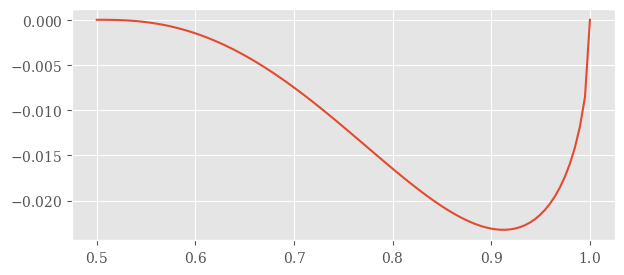

In [8]:
plt.figure(figsize=(7,3))
plt.plot(Λ_np, H_eval_np)
plt.show()
#plt.yscale('symlog',linthresh=1e-15)

Now let's test the function for different values of $\varepsilon$. In particular, we can see that the values of the curves scale as $\varepsilon^2 \log \varepsilon^2$:

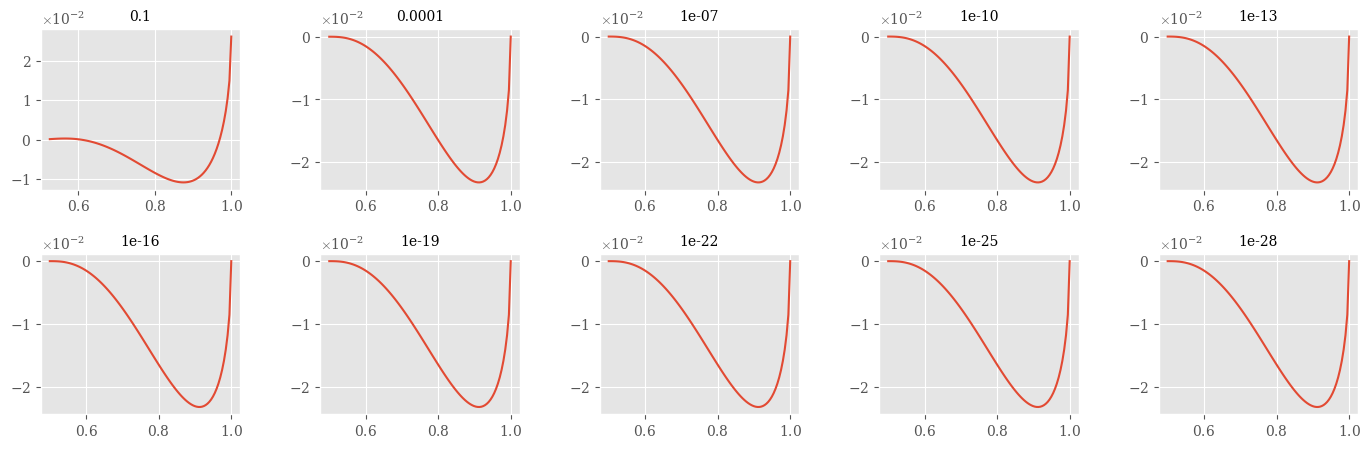

In [9]:
# Test
fig, ax = plt.subplots(nrows=2, ncols=5, figsize = (17,5))

i = 0
for ε in [mp.mpf('10') ** -a for a in range(1,31,3)]:
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Endpoint of interval
    Λ = mp.linspace(λₓ, n_1, N)                                          # Interval
    Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version
    
    H_eval_mp = [H_mp(λ, ε, False) for λ in Λ ]
    H_eval_np = np.fromiter((np.float64(x) for x in H_eval_mp), dtype=np.float64, count=N)

    if i <= 4:
        ax[0,i].plot( Λ_np, H_eval_np)
        ax[0,i].set_title(float(ε), {'fontsize':10})
        ax[0,i].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
        #ax[0,i].set_xticks([0.0,0.2,0.5])
    else:
        ax[1,i-5].plot( Λ_np, H_eval_np)
        ax[1,i-5].set_title(float(ε), {'fontsize':10})
        ax[1,i-5].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
        #ax[1,i-5].set_xticks([0.0,0.2,0.5])
    
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.4, hspace=0.4)

We observe that there seems to be a convergent behaviour with a leading term that does not depend on $\varepsilon$.

---

We have that
\begin{align*}
    H(\lambda,\varepsilon) \sim h_0(\lambda) + h_1(\lambda) \varepsilon + h_2(\lambda) \varepsilon^2 + O(\varepsilon^3),
\end{align*}
where, for $\omega_- = \arccos (2\lambda - 1)$, we have
\begin{align*}
    h_0 (\lambda) &= \frac{1}{4\pi} \left[ \Im \operatorname{Li}_2 (-e^{2 i \omega_-}) + 4(2\lambda -1) \big( 1 - \log(4\lambda - 2) \big) \sqrt{\lambda (1-\lambda)} \right]
    \\
	h_1 (\lambda) &= \frac{1}{4\pi} \left[ (2\lambda-1)(\pi - 2 \omega_-) + 2(2\lambda -1)^2 \big(1 - \log(4\lambda - 2) \big) \sqrt{\lambda (1-\lambda)} \right]
		\\
	h_2 (\lambda) &= \frac{(2\lambda - 1)^2}{8\pi} \left[ \pi - (2\lambda-1) \big(1 + 2\log(4\lambda - 2) \big) \sqrt{\lambda (1-\lambda)} \right]
    %h_2^{(2)} (\lambda) &= \frac{(2\lambda - 1)^2}{8\pi} \sbr{ \pi - (2\lambda-1) \del{1 + 2 \log(4\lambda - 2) } \sqrt{\lambda (1-\lambda)} }.
    .
\end{align*}
Observe that in such case $H(\lambda,\varepsilon) \sim h_0(\lambda)$.

In [10]:
ε = mp.mpf('10') ** -30
λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Endpoint of interval
Λ = mp.linspace(λₓ, n_1, N)                                                  # Interval
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version

H_eval_mp = [H_mp(λ, ε, False) for λ in Λ ]
H_eval_np = np.fromiter((np.float64(x) for x in H_eval_mp), dtype=np.float64, count=N)

# Compute approximation
h_0_mp = [ (mp.polylog(2, -mp.exp(2j * mp.acos(n_2*λ - n_1) ) ).imag + n_4 *(n_2 * λ - n_1) * ( 1 - mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )  for λ in Λ ]
h_1_mp = [ (n_2 * λ - n_1) * ( ( mp.pi - n_2 * mp.acos(n_2*λ - n_1) ) + n_2 *(n_2 * λ - n_1) * ( 1 - mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )  for λ in Λ ]
h_2_mp = [ (n_2 * λ - n_1)**2 * ( mp.pi - (n_2 * λ - n_1) * ( n_1 + n_2 * mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( 8.0 * mp.pi )  for λ in Λ ]

h_0_np = np.fromiter((np.float64(x) for x in h_0_mp), dtype=np.float64, count=N)
h_1_np = np.fromiter((np.float64(x) for x in h_1_mp), dtype=np.float64, count=N)
h_2_np = np.fromiter((np.float64(x) for x in h_2_mp), dtype=np.float64, count=N)

H_ε_mp = [ h_0_mp[i] + h_1_mp[i]*ε + h_2_mp[i] * ε*ε for i in range(N) ]
H_ε_np = np.fromiter((np.float64(x) for x in H_ε_mp), dtype=np.float64, count=N)

# Compute error
abs_err = np.fromiter((np.float64(abs(H_eval_mp[i] - H_ε_mp[i])) for i in range(N)), dtype=np.float64, count=N)
rel_err = np.fromiter((np.float64( abs(H_eval_mp[i] - H_ε_mp[i])/abs(H_eval_mp[i]+1e-60) ) for i in range(N)), dtype=np.float64, count=N)

In [11]:
print('λₓ behaves as ε:', mp.ceil(-mp.log10( λₓ - 0.5 )) - n_1 )

λₓ behaves as ε: 30.0


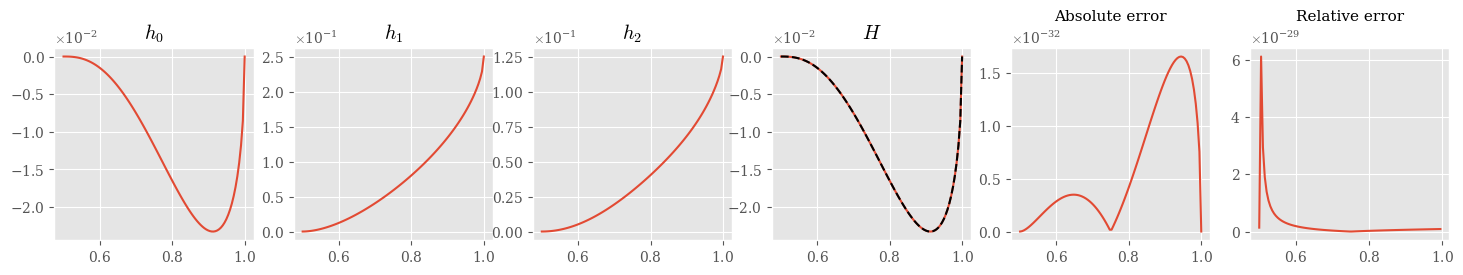

In [12]:
# Test
fig, ax = plt.subplots(nrows=1, ncols=6, figsize = (18,2.5))

ax[0].plot( Λ_np, h_0_np);                        ax[0].set_title(r'$h_0$')
ax[1].plot( Λ_np, h_1_np);                        ax[1].set_title(r'$h_1$')
ax[2].plot( Λ_np, h_2_np);                        ax[2].set_title(r'$h_2$')
ax[3].plot( Λ_np, H_eval_np);                     ax[3].set_title(r'$H$')
ax[3].plot( Λ_np, H_ε_np, '--', c='black')
ax[4].plot( Λ_np, abs_err);                        ax[4].set_title(r'Absolute error', {'fontsize':11})
ax[5].plot( Λ_np[:-1], rel_err[:-1]);              ax[5].set_title(r'Relative error', {'fontsize':11})

for i in range(6):
    ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
plt.show()

We can determine the error of this approximation:

In [13]:
from matplotlib.colors import to_hex, to_rgb
def colorFader(c1,c2,mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    c1 = np.array(to_rgb(c1))
    c2 = np.array(to_rgb(c2))
    return to_hex((1-mix)*c1 + mix*c2)
plt.style.use('default')
rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

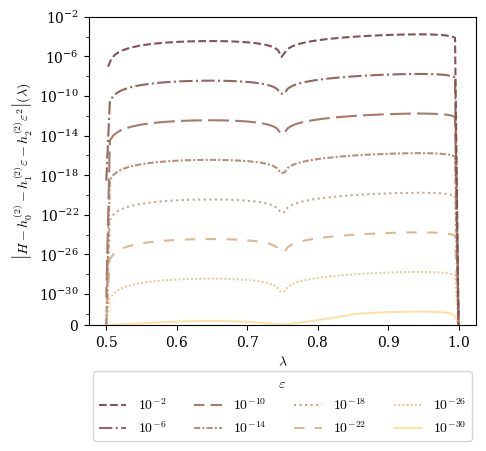

In [14]:
nA = range(30,1,-4)
E, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
linestyles = ['solid', (0, (1, 1)), (0, (5, 5)), 'dotted', (0, (3, 1, 1, 1)), (5, (10, 3)), '-.', '--']
plt.figure(figsize=(5,4))
for i in range(len(E)):
    ε = E[i]
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Endpoint of interval
    Λ = mp.linspace(λₓ, n_1, N)                                                  # Interval
    Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version
    
    # Compute exact curve
    H_eval_mp = [H_mp(λ, ε, False) for λ in Λ ]
    #H_eval_np = np.fromiter((np.float64(x) for x in H_eval_mp), dtype=np.float64, count=N)
    
    # Compute approximation
    h_0_mp = [(mp.polylog(2,-mp.exp(2j * mp.acos(n_2*λ - n_1) ) ).imag + n_4 *(n_2 * λ - n_1) * ( 1 - mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )  for λ in Λ ]
    h_1_mp = [(n_2 * λ - n_1)*( ( mp.pi - n_2 * mp.acos(n_2*λ - n_1) ) + n_2 *(n_2 * λ - n_1) * ( 1 - mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )  for λ in Λ ]
    h_2_mp = [(n_2 * λ - n_1)**2 * ( mp.pi - (n_2 * λ - n_1) * ( n_1 + n_2 * mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( 8.0 * mp.pi )  for λ in Λ ]
    
    H_ε_mp = [ h_0_mp[i] + h_1_mp[i]*ε + h_2_mp[i] * ε*ε for i in range(N) ]
    
    # Compute error curves
    abs_err = np.fromiter((np.float64(abs(H_eval_mp[i] - H_ε_mp[i])) for i in range(N)), dtype=np.float64, count=N)
    plt.plot(Λ_np, abs_err, label = leg[i], linestyle = linestyles[i], color = colorFader('#ffe1a8','#723d46',i/len(E)) )
plt.yscale('symlog', linthresh=1e-32)
#plt.yscale('log')
#plt.legend(loc='center right', bbox_to_anchor=(1.45, 0.5), ncols = 2, reverse = True, title = r'$\varepsilon$')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.4), ncols = 4, reverse = True, title = r'$\varepsilon$')
plt.ylim([0,1e-3])
plt.ylabel(r'$\left| H - h_0^{(2)} - h_1^{(2)} \varepsilon - h_2^{(2)} \varepsilon^2 \right| (\lambda)$')
plt.xlabel(r'$\lambda$')
y_ticks = plt.yticks()
plt.yticks(y_ticks[0][::2], y_ticks[1][::2])
# –––––––– Store –––––––– #
plt.savefig('Absolute_error_2.pdf', bbox_inches='tight', pad_inches=0)
#plt.grid()
plt.show()

Finally, we can determine the maximum absolute error of the approximation:

In [15]:
E = [mp.power(mp.mpf('10.0'),a) for a in mp.linspace(-30,-4,100)]
abs_err = np.zeros(len(E))
for i in range(len(E)):
    ε = E[i]
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Endpoint of interval
    Λ = mp.linspace(λₓ, n_1, N)                                                  # Interval
    Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version
    
    # Compute exact curve
    H_eval_mp = np.asarray([H_mp(λ, ε, False) for λ in Λ ])
    
    # Compute approximation
    h_0_mp = [(mp.polylog(2,-mp.exp(2j * mp.acos(n_2*λ - n_1) ) ).imag + n_4 *(n_2 * λ - n_1) * ( 1 - mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )  for λ in Λ ]
    h_1_mp = [(n_2 * λ - n_1)*( ( mp.pi - n_2 * mp.acos(n_2*λ - n_1) ) + n_2 *(n_2 * λ - n_1) * ( 1 - mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( n_4 * mp.pi )  for λ in Λ ]
    h_2_mp = [(n_2 * λ - n_1)**2 * ( mp.pi - (n_2 * λ - n_1) * ( n_1 + n_2 * mp.log(n_4 * λ - n_2) ) * mp.sqrt(λ * (n_1 - λ))) / ( 8.0 * mp.pi )  for λ in Λ ]
    
    H_ε_mp = [ h_0_mp[i] + h_1_mp[i]*ε + h_2_mp[i] * ε*ε for i in range(N) ]
    
    # Compute error curves
    #abs_err[i] = np.float64(mp.sqrt(((np.asarray(H_eval_mp) - np.asarray(H_ε_mp))**2).sum()))
    abs_err[i] = np.float64(np.linalg.norm( H_eval_mp - H_ε_mp, ord=np.inf ))

In [16]:
x = np.log(np.asarray(E).astype(np.float64))
y = np.log(abs_err)
fitting = np.linalg.lstsq(np.vstack([x, np.ones_like(x)]).T, y, rcond=None)[0]
fitting, np.exp(fitting[1]).item()

(array([ 1.        , -4.09996038]), 0.01657333195581875)

The maximum error behaves like $\varepsilon \, (1.5 \times 10^{-2})$:

In [17]:
plt.style.use('ggplot')

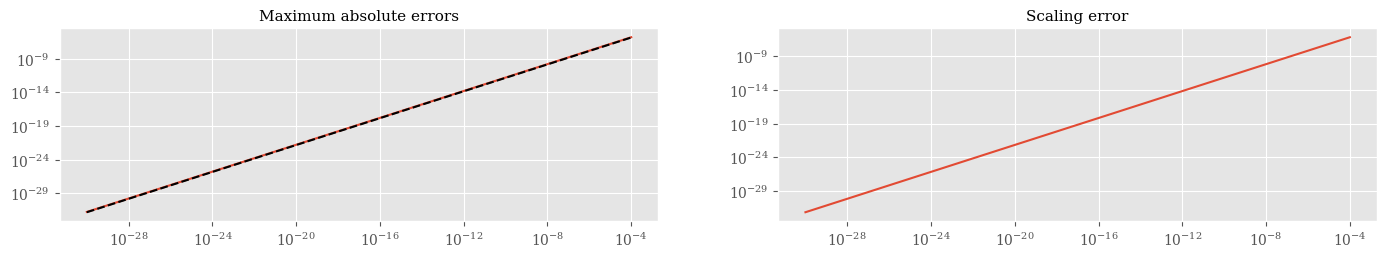

In [18]:
# Test
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (17,2.5))


ax[0].plot(E, abs_err);                                 ax[0].set_title(r'Maximum absolute errors', {'fontsize':11})
ax[0].plot(E, np.asarray(E)*0.015, '--', c = 'black' )
#ax[0].plot(E, np.exp(fitting[0] * x + fitting[1]), '--', c = 'black' )
ax[0].set_yscale('log')
ax[0].set_xscale('log')


ax[1].plot(E, abs(abs_err - np.asarray(E)*0.01));       ax[1].set_title(r'Scaling error', {'fontsize':11})
ax[1].set_yscale('log')
ax[1].set_xscale('log')

plt.show()

Knowing that
\begin{align*}
    \partial_\lambda h_0(\lambda) = \frac{ (2\lambda-1)^2 }{ 2\pi \sqrt{\lambda (1-\lambda)} } \big( 2 \log( 4 \lambda - 2 ) -1  \big),
\end{align*}
then the local maximiser lies asymptotically at $\lambda = \frac{1}{2} + \frac{1}{4} e^{1/2}$.

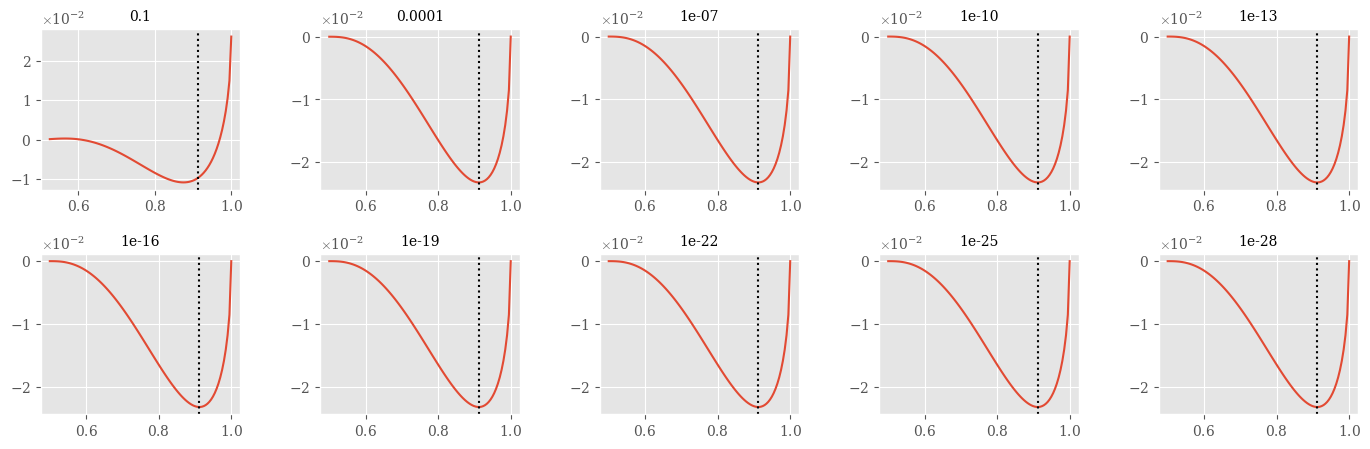

In [19]:
# Test
fig, ax = plt.subplots(nrows=2, ncols=5, figsize = (17,5))

i = 0
for ε in [mp.mpf('10') ** -a for a in range(1,31,3)]:
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Endpoint of interval
    Λ = mp.linspace(λₓ, n_1, N)                                          # Interval
    Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version
    
    H_eval_mp = [H_mp(λ, ε, False) for λ in Λ ]
    H_eval_np = np.fromiter((np.float64(x) for x in H_eval_mp), dtype=np.float64, count=N)

    if i <= 4:
        ax[0,i].plot( Λ_np, H_eval_np)
        ax[0,i].set_title(float(ε), {'fontsize':10})
        ax[0,i].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
        #ax[0,i].set_xticks([0.0,0.2,0.5])
        ax[0,i].axvline(x=np.exp(1/2)/4 + 0.5, color='black', linestyle = ':')
    else:
        ax[1,i-5].plot( Λ_np, H_eval_np)
        ax[1,i-5].set_title(float(ε), {'fontsize':10})
        ax[1,i-5].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
        #ax[1,i-5].set_xticks([0.0,0.2,0.5])
        ax[1,i-5].axvline(x=np.exp(1/2)/4 + 0.5, color='black', linestyle = ':')
    
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.4, hspace=0.4)

---